# Building pipelines for BARRA2
This notebook builds on the 'Accessing BARRA-R2' notebook. The variable transformations
used in the previous notebook, are now applied in PyEarthTool (PET) pipelines.
At the end of this notebook we will have:
- loaded BARRA-R2 and ERA5 data,
- defined our own transformation and operation classes,
- build pipelines for surface and pressure level variables,
  as well as pipelines for average and instananeous variables.
- plotted the first time step of BARRA-R2 and ERA5 for comparison.

In [1]:
import sys
sys.path.insert(0,"/home/565/cst565/.local/lib/python3.11/site-packages")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import dask.distributed
import cartopy.crs as ccrs

from typing import Callable, Optional

# Load PET specific modules and NCI settings
import pyearthtools
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

import warnings
warnings.filterwarnings('ignore')

In [2]:
pyearthtools.__path__

_NamespacePath(['/home/565/cst565/projects/PyEarthTools/packages/data/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/pipeline/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/training/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/tutorial/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/utils/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/zoo/src/pyearthtools', '/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools'])

## Classes
We need to write some of our own PET Transformation and PET Operation classes to perform the necessary variable conversion.

They won't be used until later but it is good practice to define classes at the top of a script.

The Transformations we need to define are a class to:

- multiply a dataarray with a constant,
- divide a dataarray with a constant,
- add two dataarrays together and,
- subtract two dataarrays from each other.

In [3]:
class MultiplyConstant(petdata.transforms.transform.Transform):
    """Multiply variable in dataset with a constant."""

    def __init__(
        self,
        **factors: dict[str, int | float],
    ):
        """
        Multiply all values of a variable with a constant factor.

        Args:
            factors (dict):
                A dictionary of variable names and factor value pairings 
                (e.g., {'name':2}, will lead to variable with 'name' to be doubled).
        """
        super().__init__()
        self.record_initialisation()

        self._factors = factors

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        for key in self._factors.keys():
            try:
                dataset[key] = dataset[key] * self._factors[key]
            
            except KeyError as e:
                raise DataNotFoundError(f"Variable with name {key} not found in dataset!") from e
        return dataset


class DivideConstant(petdata.transforms.transform.Transform):
    """Divide variable in dataset with a constant."""

    def __init__(
        self,
        **divisors: dict[str, int | float],
    ):
        """
        Divide all values of a variable with a constant factor.

        Args:
            divisors:
                A dictionary of variable names and divisor value pairings 
                (e.g., {'name':2}, will lead to variable with 'name' to be halved).
        """
        super().__init__()
        self.record_initialisation()

        self._divisors = divisors

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        for key in self._divisors.keys():
            try:
                dataset[key] = dataset[key] / self._divisors[key]
            
            except KeyError as e:
                raise DataNotFoundError(f"Variable with name {key} not found in dataset!") from e
        return dataset


class AddDataArray(petdata.transforms.transform.Transform):
    """Add two variables from the same dataset."""

    def __init__(
        self,
        **summands: str,
    ):
        """
        Add two variables from the same dataset.

        Args:
            summands:
                A dictionary of summands. The key of the dict is the variable name of the
                first summand and result, while the value is the second summand.
                Follows: dataset[key] = dataset[key] + dataset[value].
        """
        super().__init__()
        self.record_initialisation()

        self._summands = summands

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        for key in self._summands.keys():
            try:
                dataset[key] = dataset[key] + dataset[self._summands[key]]
            
            except KeyError as e:
                raise DataNotFoundError(f"Variables with names {key} or {self._summands[key]} not found in dataset!") from e
        return dataset


class SubtractDataArray(petdata.transforms.transform.Transform):
    """Subtract two variables from the same dataset."""

    def __init__(
        self,
        **subtrahends: str,
    ):
        """
        Subtract two variables from the same dataset.

        Args:
            subtrahends:
                A dictionary of subtrahends. The key of the dict is the variable name of the
                minuend and result, while the value is the subtrahend.
                Follows: dataset[key] = dataset[key] - dataset[value].
        """
        super().__init__()
        self.record_initialisation()

        self._subtrahends = subtrahends

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        for key in self._subtrahends.keys():
            try:
                dataset[key] = dataset[key] - dataset[self._subtrahends[key]]
            
            except KeyError as e:
                raise DataNotFoundError(f"Variables with names {key} or {self._subtrahends[key]} not found in dataset!") from e
        return dataset

We also need to define a PET Operation that allows us to modify the valid times of a dataset.

This is needed because for accumulations BARRA2 uses the convention that the valid time should be in the middle of the
time bounds used for aggregation (e.g., if a value is aggregated from 0 UTC to 1 UTC, BARRA would assign a valid time of 00:30 UTC), while ERA5's convention is to use the upper bound as valid time (e.g., for the same aggregated variable ERA5 uses a valid time of 1 UTC).

In [4]:
class RoundTime(petpipe.operation.Operation):
    """Round the time coordinate to the nearst hour."""

    _override_interface = "Serial"

    def __init__(
        self,
        freq: str,
        fun: Optional[Callable | str] = None
    ):
        """
        Round timestamps to specified frequency resolution. For example time values
        like 00:30UTC become 01:00UTC.
        Wrapper of xarray.DataArray.dt.round

        Args:
            freq (str):
                a freq string indicating the rounding resolution e.g. “D” for daily resolution
            fun (Callable, optional):
                function to use when rounding. Default is 'round'
            
        """
        super().__init__(
            split_tuples=True,
            operation="apply",
            recognised_types=(xr.Dataset, xr.DataArray),
        )
        
        self._freq = freq
        self._fun = fun
        self._default_fun = "round"
        self._known_methods = ["round", "ceil", "floor"]
        self._known_freq = ['H', 'D']

        if self._fun is None:
            self._fun = self._default_fun

        if not self._fun in self._known_methods:
            raise KeyError(f"Rounding function of {self._fun} not found in {self._known_methods}")

        if not self._freq in self._known_freq:
            raise KeyError(f"freq of {self._freq} not implemented! Only {self._known_freq} accepted!")

        self.record_initialisation()

    def apply_func(self, dataset: xr.Dataset) -> xr.Dataset:
        # Get the function from the dataset directly
        _fun = getattr(dataset['time'].dt, self._fun)

        # Get the new time steps and make sure they are pandas timestamps
        newtime = _fun(self._freq)
        newtime = [pd.Timestamp(a) for a in newtime.values]

        # Assign the new time values to the time coordinate
        dataset = dataset.assign_coords({"time": newtime})

        return dataset

## Main
Now we can start with the main code.

First, lets start a dask client to help with computation.

In [5]:
client = dask.distributed.Client(n_workers = 25, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41129/status,
Dashboard: /proxy/41129/status,Workers: 25
Total threads: 25,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44705,Workers: 0
Dashboard: /proxy/41129/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34839,Total threads: 1
Dashboard: /proxy/39703/status,Memory: 2.52 GiB
Nanny: tcp://127.0.0.1:34929,


2025-10-24 12:37:26,192 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('getitem-6f07e800c66d14c3f16acfc8d766502a', 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('getitem-6f07e800c66d14c3f16acfc8d766502a', 0, 0) getitem(...)>
new run_spec: Alias(('getitem-6f07e800c66d14c3f16acfc8d766502a', 0, 0)->('interpnd-interpnd_0-transpose-getitem-6f07e800c66d14c3f16acfc8d766502a', 0, 0))
old dependencies: {('transpose-967c824d863366d2aafc094694fd0c7e', 0, 0, 0)}
new dependencies: frozenset({('interpnd-interpnd_0-transpose-getitem-6f07e800c66d14c3f16acfc8d766502a', 0, 0)})

2025-10-24 12:37:46,

And then we can define the list of variables we want, as well as a mapping between the names in BARRA2 and ERA5.

Based on these variables lists, we can then build all the data accessors we need.

In [6]:
varlist_hourly_instant = [
    'tas', # surface temperature
    'uas', # 10m u-winds
    'vas', # 10m v-winds
    'psl', # mean sea level pressure
    'prw', # water vapour path,
]

varlist_hourly_instant_plev = [
    'ta500', # temperature at 500hPa
    'ua500', # u-wind at 500hPa
    'va500', # v-winds at 500hPa
    'omega500', # pressure velocity at 500hPa
    'hus500', # specific humidity at 500hPa
    'zg500', # geopotential at 500hPa
]

varlist_hourly_averaged = [
    'pr', # hourly average precipitation
    'clt', # hourly average cloud cover
    'rsdt', # hourly average TOA Incident Shortwave Radiation
    'rsds', # hourly average shortwave down surface
    'rsut', # hourly average TOA outgoing shortwave
    'rlus', # hourly averaged longwave up surface
    'rlds', # hourly average longwave down surface
    'rlut', # hourly average TOA outgoing longwave
]

# The full varlist is
varlist = varlist_hourly_instant + varlist_hourly_averaged + varlist_hourly_instant_plev

In [7]:
barra2era_map = {
    'tas': '2t',
    'ta500': 't',
    'uas': 'u10n',
    'ua500': 'u',
    'vas': 'v10n',
    'va500': 'v',
    'omega500': 'w',
    'hus500': 'q',
    'ps': 'sp',
    'psl': 'msl',
    'prw': 'tcw',
    'pr': 'tp',
    'clt': 'tcc',
    'zg500': 'z',
    # following https://www.ecmwf.int/sites/default/files/elibrary/2015/18490-radiation-quantities-ecmwf-model-and-mars.pdf
    'rsdt': 'tisr', # J m-2
    'rsds': 'ssrd', # J m-2
    'rsut': 'tsr', # tisr - tsr, J m-2
    'rlus': 'str', # strd - str, J m-2
    'rlds': 'strd', # J m-2
    'rlut': 'ttr', # J m-2
}

In [8]:
# BARRA-R2 accessor
barra2_hinstant = petdata.archive.BARRA_V2(varlist_hourly_instant+varlist_hourly_instant_plev, domain_id='AUS-11', frequency='1hr')

# In ERA5, accumulations are over the hour (the accumulation/processing period)
# ending at the validity date/time, while in BARRA2 the valid time is in the middle
# of the aggregation period.
# To make both match, we round the valid time in BARRA2 to the neearst larger hour (e.g., 00:30UTC becomes 01:00UTC)
# For this I created a transformation to be used when creating the accessor
barra2_haveraged = petdata.archive.BARRA_V2(
    varlist_hourly_averaged,
    domain_id='AUS-11',
    frequency='1hr',
)

# ERA5 accessor
era5_surface = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant + varlist_hourly_averaged], product='reanalysis')
era5_plev = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant_plev], product='reanalysis')

## Build the pipeline
Building on the previous notebook of accessing barra2 data and plotting climatologies and histograms we know what variable transformations are needed to match up between BARRA2 and ERA5.

And using the transformation and operation classes we have defined and the beginning of the notebook, we can now do the same things using PET pipelines.

As in the previous notebook, we need to re-grid ERA5 to match the BARRA-R2 horizontal resolution. This is only needed because we want to plot some time steps for comparisons after setting up out pipelines. Those comparison plots will help us verify that we have setup the pipelines correctly and they behave as we expect.

For the re-gridding we need to define the reference grid (ref_grid) as below.

In [9]:
ref_grid = barra2_hinstant['1979-01-01 00:00']['tas'].squeeze()
ref_grid

<xarray.DataArray 'tas' (height: 2, latitude: 646, longitude: 1082)> Size: 11MB
dask.array<getitem, shape=(2, 646, 1082), dtype=float64, chunksize=(1, 104, 208), chunktype=numpy.ndarray>
Coordinates:
    time       datetime64[ns] 8B 1979-01-01
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
  * height     (height) float64 16B 1.5 10.0
    crs        int32 4B ...
Attributes:
    long_name:      Near-Surface Air Temperature
    standard_name:  air_temperature
    units:          K
    cell_methods:   time: point (interval: 1H)
    grid_mapping:   crs

In [10]:
def mean_height(dataset):
    return dataset.mean('height')

In [11]:
variable_rename = {
    'ta': 'ta500',
    'ua': 'ua500',
    'va': 'va500',
    'omega': 'omega500',
    'hus': 'hus500',
    'zg': 'zg500',
}

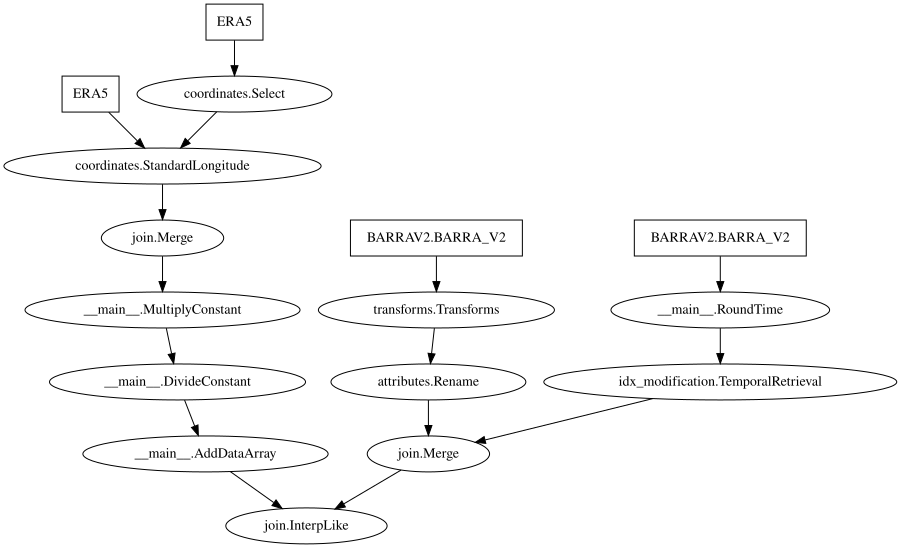

In [12]:
pipe_era5_surface = petpipe.Pipeline(
    era5_surface,
)

pipe_era5_plev = petpipe.Pipeline(
    era5_plev,
    petdata.transforms.coordinates.Select({"level":500})
)

pipe_era5 = petpipe.Pipeline(
    (pipe_era5_surface, pipe_era5_plev),
    petdata.transforms.coordinates.StandardLongitude(type="0-360"),
    petpipe.operations.xarray.Merge(),
    MultiplyConstant(
        tcc=100,
        tp=1000
    ),
    DivideConstant(
        tp=3600,
        z=9.81,
        tisr=3600,
        ssrd=3600,
        strd=3600,
        ttr=-3600,
        tsr=-3600, 
        str=-3600
    ),
    AddDataArray(
        tsr='tisr',
        str='strd'
    ),
)

pipe_barra_instant = petpipe.Pipeline(
    barra2_hinstant,
    petpipe.operations.Transforms(mean_height),
    petdata.transforms.attributes.Rename(
            {var: variable_rename[var] for var in variable_rename.keys()}
        )
)

pipe_barra_average = petpipe.Pipeline(
    barra2_haveraged,
    # The updating of the valid time for the averaged variables
    # is a two-step process. First, we ceil the times to the nearest hour
    # (e.g., 00:30, becomes 01:00) and then we have to tell PET, 
    # that the old index, with hour 00, now belongs to hour 01.
    # In PET terms this means shift the index back by one (-1) and retrieve 1 time step
    RoundTime("H", 'ceil'),
    petpipe.modifications.idx_modification.TemporalRetrieval((-1,1)),
)

pipe_barra = petpipe.Pipeline(
    (pipe_barra_instant, pipe_barra_average),
    petpipe.operations.xarray.Merge(),
)

pipe = petpipe.Pipeline(
    (pipe_era5, pipe_barra),
    petpipe.operations.xarray.join.InterpLike(ref_grid),
)
pipe

## Plotting and verification
Now that we have defined the individual pipelines and combined all the individual pipelines in the final pipeline, we plot the first time step to confirm that it works as we expect it to!

Please note that some differences between ERA5 and BARRA-R2 are to be expected. In particulay for variables that are very sensitive to the higher horizontal resolution of BARRA-R2, such as precipitation (pr), vertical velocity (omega500), cloud cover (clt) and some radiation fields that are influenced by clouds (rsds, rsut).

The differences are also expected to be larger than in the previous notebook because we are looking at snapshots in time rather than monthly averaged fields.

In [ ]:
nrows = len(varlist)
fig, axs = plt.subplots(nrows,3, figsize=((10,4*nrows)),subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Let's define the colour range for easier comparison
vminmax = {
    'tas': (270,310),
    'ta500': (240,270),
    'uas': (-10,10),
    'ua500': (-25,25),
    'vas': (-10,10),
    'va500': (-5,5),
    'omega500': (-0.5,0.5),
    'huss': (None, None),
    'hus500': (None, None),
    'ps': (75000,101000),
    'psl': (97000,102000),
    'prw': (10,60),
    'pr': (0,5e-4),
    'clt': (0,100),
    'rsdt': (320,500),
    'rsds': (150,400),
    'rsut': (50,210),
    'rlus': (300,520),
    'rlds': (300,420),
    'rlut': (150,300),
    'zg500': (5200, 5800),
}

# Plot all variable comparisons
for i, var in enumerate(varlist):
    # Get the first sample
    sample = pipe['1979-01-01 01:00']
    a = sample[var].squeeze()
    b = sample[barra2era_map[var]].squeeze()
    r = xr.corr(
        a,
        b
    ).values
    b.plot.pcolormesh(ax=axs[i,0], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    a.plot.pcolormesh(ax=axs[i,1], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    (b-a).plot.pcolormesh(ax=axs[i,2], robust=True, transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    axs[i,0].set_title(f"ERA5 - {var}")
    axs[i,1].set_title(f"BARRA2 - {var}")
    axs[i,2].set_title(f"ERA5 minus BARRA-R2 (r={r:.2f})")